<a href="https://colab.research.google.com/github/9terry-student/PyTorch/blob/main/17_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 17장 세상에 없는 얼굴 GAN, 오토 인코더

## 3. 적대적 신경망 실행하기

### 실습: GAN 모델 만들기

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_87"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 28, 28, 1)      │       865,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,146 (4.11 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 225,537 (881.00 KB)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
epoch:0  d_loss:0.6807  g_loss:0.6223
epoch:100  d_loss:0.4860  g_loss:0.4054
epoch:200  d_loss:0.4693  g_loss:0.4431
epoch:300  d_loss:0.5511  g_loss:0.5309
epoch:400  d_loss:0.5964  g_loss:0.5925
epoch:500  d_loss:0.6202  g_loss:0.6312
epoch:600  d_loss:0.6320  g_loss:0.6575
epoch:700  d_loss:0.6366  g_loss:0.6809
epoch:800  d_loss:0.6383  g_loss:0.7010
epoch:900  d_loss:0.6373  g_loss:0.7204
epoch:1000  d_loss:0.6365  g_loss:0.7364
epoch:1100  d_loss:0.6404  g_loss:0.7394
epoch:1200  d_loss:0.6445  g_loss:0.7421
epoch:1300  d_loss:0.6472  g_loss:0.7469
epoch:1400  d_loss:0.6496  g_loss:0.7519
epoch:1500  d_loss:0.6517  g_loss:0.7558
epoch:1600  d_loss:0.6533  g_loss:0.7576
epoch:1700  d_loss:0.6552  g_loss:0.7593
epoch:1800  d_loss:0.6564  g_loss:0.7606
epoch:1900  d_loss:0.6578  g_loss:0.7618
epoch:2000  d_loss:0.6588  g_loss:0.7627
epoch:2100  d_loss:0.6598  g_loss:0.7636
epoch:2200  d_loss:0.6606  g_loss:0.7644
epoch:2300  d_loss

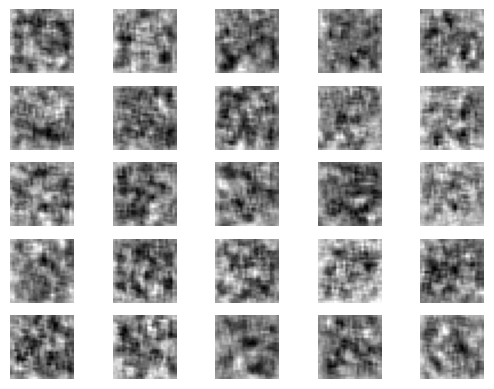

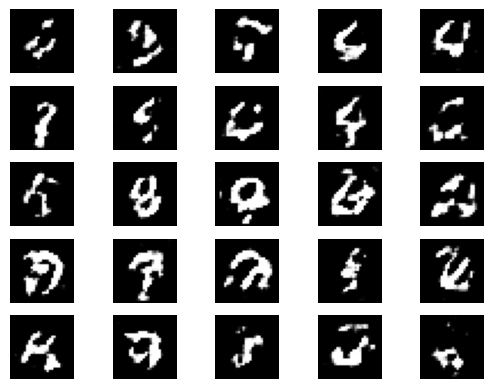

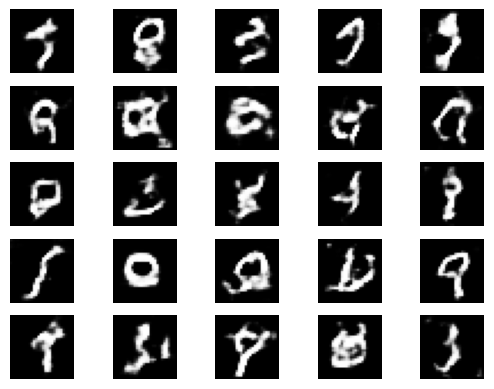

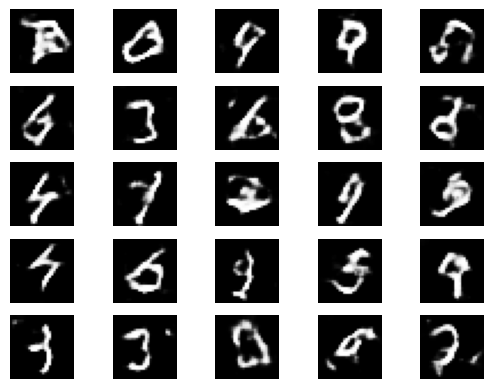

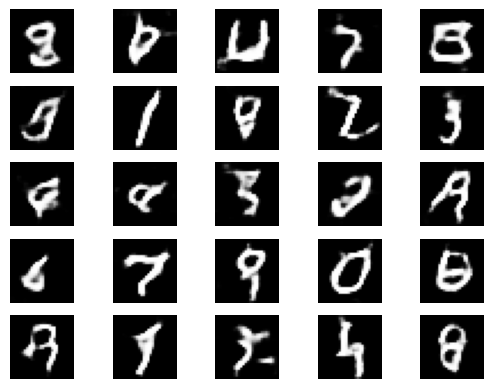

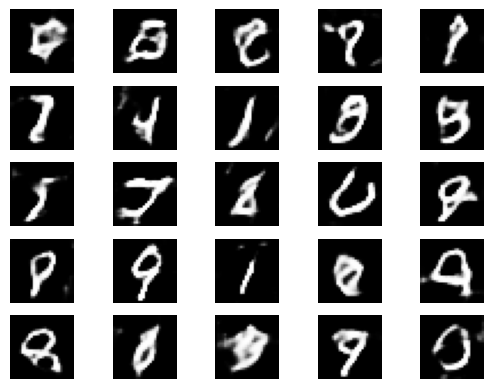

In [7]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input,Dense,Reshape,Flatten,Dropout
from tensorflow.keras.layers import BatchNormalization,Activation,LeakyReLU,UpSampling2D,Conv2D
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('./data/gan_images',exist_ok=True)

# 생성자 모델 생성
generator=Sequential()
generator.add(Dense(128*7*7,input_dim=100,activation=LeakyReLU(0.2)))
generator.add(BatchNormalization())
generator.add(Reshape((7,7,128)))
generator.add(UpSampling2D())
generator.add(Conv2D(64,kernel_size=5,padding='same'))
generator.add(BatchNormalization())
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1,kernel_size=5,padding='same',activation='tanh'))

# 판별자 모델 생성
discriminator=Sequential()
discriminator.add(Conv2D(64,kernel_size=5,strides=2,input_shape=(28,28,1),padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Conv2D(128,kernel_size=5,strides=2,padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())
discriminator.add(Dense(1,activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.0002,beta_1=0.5),
                                                                metrics=['accuracy'])
discriminator.trainable=False

# 생성자와 판별자 모델 연결시키는 GAN 모델 생성
ginput=Input(shape=(100,))
dis_output=discriminator(generator(ginput))
gan=Model(ginput,dis_output)
gan.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.0002,beta_1=0.5))
gan.summary()

# 신경망 실행 함수 생성
def gan_train(epoch,batch_size,saving_interval):

  # MNIST 데이터 호출
  (X_train,_),(_,_)=mnist.load_data()     # 앞서 불러온 적 있는 MNIST를 다시 이용합니다. 단, 테스트 과정은 필요 없고 이미지만 사용할 것이기 때문에 X_train만 불러왔습니다.
  X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32')
  X_train=(X_train-127.5)/127.5     # 픽셀 값은 0에서 255 사이의 값입니다. 이전에 255로 나누어 줄때는 이를 0~1 사이의 값으로 바꾸었던 것인데, 여기서는 127.5를 빼준 뒤 127.5로 나누어 줌으로 인해 -1에서 1사이의 값으로 바뀌게 됩니다.

  true=np.ones((batch_size,1))
  fake=np.zeros((batch_size,1))

  for i in range(epoch):
    discriminator.trainable=True
    # 판별자에 실제 데이터 입력
    idx=np.random.randint(0,X_train.shape[0],batch_size)
    imgs=X_train[idx]
    d_loss_real=discriminator.train_on_batch(imgs,true)

    # 판별자에 가상 이미지 입력
    noise=np.random.normal(0,1,(batch_size,100))
    gen_imgs=generator.predict(noise,verbose=0)
    d_loss_fake=discriminator.train_on_batch(gen_imgs,fake)

    # 판별자와 생성자의 오차 계산
    d_loss=0.5*np.add(d_loss_real,d_loss_fake)
    discriminator.trainable=False

    noise=np.random.normal(0,1,(batch_size,100))
    g_loss=gan.train_on_batch(noise,true)

    if i%100==0:
      print('epoch:%d'%i,' d_loss:%.4f'%d_loss[0],' g_loss:%.4f'%g_loss)

    # 중간 과정을 이미지로 저장, 생성 이미지는 gan_images 폴더에 저장
    if i%saving_interval==0:
      # r,c=5,5
      noise=np.random.normal(0,1,(25,100))
      gen_imgs=generator.predict(noise,verbose=0)

      # Rescale images 0 - 1
      gen_imgs=0.5*gen_imgs+0.5

      fig,axs=plt.subplots(5,5)
      count=0
      for j in range(5):
        for k in range(5):
          axs[j,k].imshow(gen_imgs[count,:,:,0],cmap='gray')
          axs[j,k].axis('off')
          count+=1
      fig.savefig('./data/gan_images/gan_mnist_%d.png'%i)
gan_train(4001,32,800)      # 4000번 반복, 배치 사이즈 32, 800번 마다 결과 저장

## 4. 이미지의 특징을 추출하는 오토인코더

### 실습: 오토인코더 실습하기

In [9]:
from ast import PyCF_ALLOW_TOP_LEVEL_AWAIT
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,UpSampling2D,Flatten,Reshape

import matplotlib.pyplot as plt
import numpy as np

# MNIST 데이터셋 호출
(X_train,_),(X_test,_)=mnist.load_data()
X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32')/255
X_test=X_test.reshape(X_test.shape[0],28,28,1).astype('float32')/255

# 생성자 모델 생성
autoencoder=Sequential()

# 인코딩 부분
autoencoder.add(Conv2D(16,kernel_size=3,padding='same',input_shape=(28,28,1),activation='relu'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, strides=2, padding='same', activation='relu'))

# 디코딩 부분
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(1, kernel_size=3, padding='same', activation='sigmoid'))

# 전체 구조
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.2069 - val_loss: 0.1366
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1270 - val_loss: 0.1183
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1156 - val_loss: 0.1105
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1095 - val_loss: 0.1071
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1055 - val_loss: 0.1024
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1027 - val_loss: 0.1002
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1006 - val_loss: 0.0983
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0988 - val_loss: 0.0969
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0974 - val_loss: 0.0955
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0962 - val_loss: 0.0946
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0950 - val_loss: 0.0931
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/st

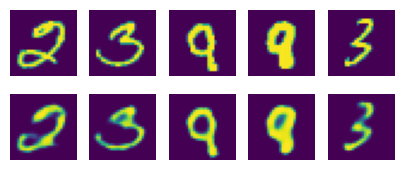

In [10]:
# 컴파일 및 학습 부분
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(X_train,X_train,epochs=50,batch_size=128,validation_data=(X_test,X_test))

# 학습 결과 출력
random_test=np.random.randint(X_test.shape[0],size=5)     # 테스트할 이미지 랜덤 호출
ae_imgs=autoencoder.predict(X_test)     # 오토인코더 모델에 넣기

plt.figure(figsize=(7,2))      # 출력 이미지 크기

for i,image_idx in enumerate(random_test):      # 랜덤 이미지 차례로 나열
  ax=plt.subplot(2,7,i+1)
  plt.imshow(X_test[image_idx].reshape(28,28))      # 테스트 이미지 먼저 표시
  ax.axis('off')
  ax=plt.subplot(2,7,7+i+1)
  plt.imshow(ae_imgs[image_idx].reshape(28,28))     # 오토인코딩 결과 출력
  ax.axis('off')
plt.show()